In [1]:
from env import config, environment, loghelper
from methods import RandomScaling


class TrainAndTestHelper(object):
    def __init__(self, env: environment.DataCenterEnvironment, agent: RandomScaling.RandomScalingAgent, logger: loghelper.LogHelper):
        self.env = env
        self.agent = agent
        self.logger = logger

    def test(self):
        total_reward = 0
        done = False
        state = self.env.reset()

        while(not done):
            action = self.agent.get_action(state)
            next_state, reward, done, info = self.env.step(action)
            total_reward += reward
            state = next_state
            for key in info:
                self.logger.record(key, info[key])

        print("total_reward: ", total_reward)
        self.logger.visualize()

total_reward:  -1261.2998220986278


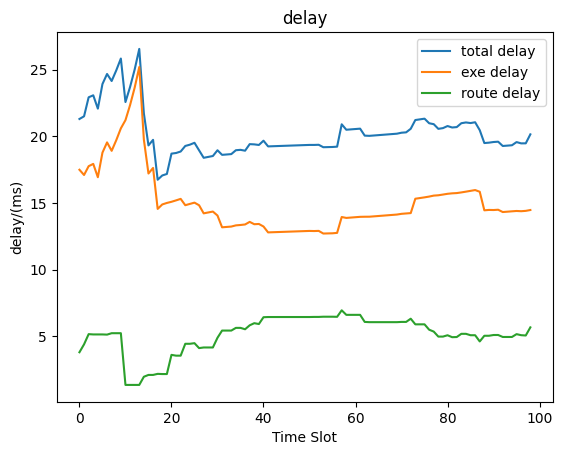

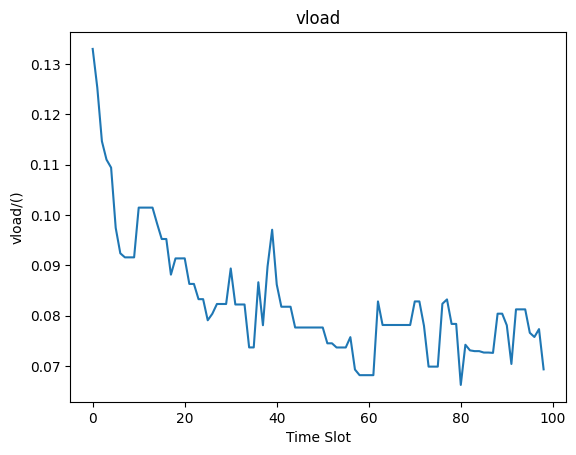

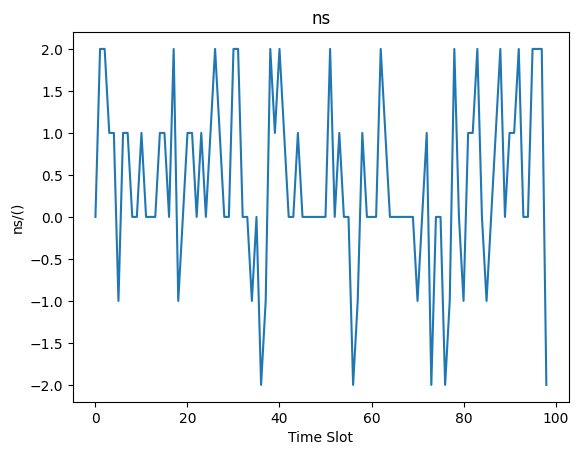

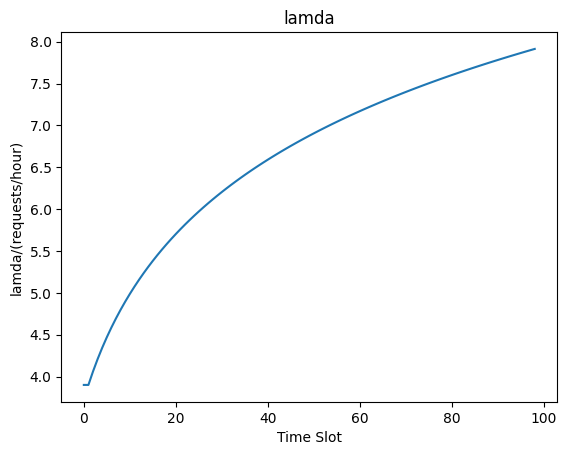

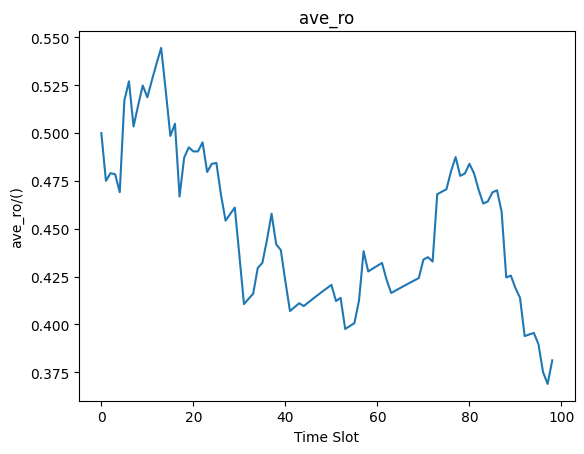

In [2]:
env_config = config.EnvConfig()
env = environment.DataCenterEnvironment(env_config)
agent = RandomScaling.RandomScalingAgent(env)
logger = loghelper.LogHelper()
train_and_test_helper = TrainAndTestHelper(env, agent, logger)
train_and_test_helper.test()